<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
import serial
import gc

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path

from datetime import datetime
import json

c:\Users\hlab_\anaconda3\envs\qickdawg_jeree\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to Laser and Board</h2>
</div>

In [2]:
qd.start_client('10.225.208.77')
ser_laser = serial.Serial(
    port='COM3',
    baudrate=9600,
    stopbits=1,
    bytesize=8,
    parity='N',
    xonxoff=True)

ser_laser.write(b'*ON\r')
ser_laser.write(b'LAS\r')

4

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Laser Functions</h2>
</div>

In [3]:
def On():
    qd.laser_on(default_config)
    
def Off():
    SetPower(0)

def SetPower(power):
    command = f'PWR{power}\r'.encode()
    ser_laser.write(command)

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Setup Saving</h2>
</div>

In [4]:
# Parent directory where all measurement data is saved
parent_save_dir = Path(r"Z:\Data\DefectMsmts\Data\Albania")

# Create it if it doesn't already exist (safe to run even if it does)
parent_save_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {parent_save_dir}")
print(f"Exists: {parent_save_dir.exists()}")

Saving to: Z:\Data\DefectMsmts\Data\Albania
Exists: True


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Save Functions</h3>
</div>

In [5]:
def create_experiment_folder(subfolder_name, parent_dir=parent_save_dir):
    """
    Creates a new timestamped, numbered experiment folder inside
    parent_dir/subfolder_name, and returns the Path to it.
    """
    subfolder_path = parent_dir / subfolder_name
    subfolder_path.mkdir(parents=True, exist_ok=True)

    # Count existing experiment folders to figure out the next experiment number
    existing_experiments = [p for p in subfolder_path.iterdir() if p.is_dir()]
    experiment_number = len(existing_experiments) + 1

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    experiment_folder = subfolder_path / f"{timestamp}_{experiment_number:03d}"
    experiment_folder.mkdir(parents=True, exist_ok=False)

    return experiment_folder

def save_metadata(run_folder, params: dict, filename="metadata.json"):
    with open(run_folder / filename, "w") as f:
        json.dump(params, f, indent=4)

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">0. Assigning Default Configurations for Pulsing: NVConfiguration</h2>
</div>
<a class="anchor" id="first-bullet"></a>

In [6]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 1
default_config.edge_counting = True

# Hysteresis thresholds prevent double-counting from noise: signal must rise above high_threshold to register a photon, then fall below low_threshold before it can register the next one
default_config.high_threshold = 8000
default_config.low_threshold = 500


default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0
default_config.adc_trigger_pmod = 1

default_config.readout_integration_tus = 3
default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom


In [ ]:
# qd.soc.reset_gens()   



<div style="background-color:#FF0000; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Run ALL Above Here For Initialization</h2>
</div>
<a class="anchor" id="first-bullet"></a>




<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">1. Turn Laser On and Off</h2>
</div>
<a class="anchor" id="first-bullet"></a>


In [10]:
SetPower(0.1)



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">3 ODMR</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Time Estimate </h3>
</div>

In [35]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 40
mw_gain = 2000
reps = 1000
relax_delay_treg = 500
sweep_start_fGHz = 1.5
sweep_stop_fGHz = 2.5
sweep_step_fGHz = 0.005
nd_filter_OD = 0

config.readout_integration_tus = qd.max_int_time_tus
config.mw_gain = mw_gain
config.pre_init = True
config.reps = reps
config.relax_delay_treg = relax_delay_treg

config.add_linear_sweep('mw', 'fGHz', start=sweep_start_fGHz, stop=sweep_stop_fGHz, delta=sweep_step_fGHz)

# ---- Estimate runtime (no hardware call yet) ----
prog = qd.LockinODMR(config)
est_seconds = prog.total_time()
print(f"Estimated runtime: {est_seconds/60:.1f} min")


Requested 1.5 to 2.5 by 0.005
Instead using 1.5 to 2.5000000762939454 by 0.005000000381469726 in 201 steps
Estimated runtime: 1.4 min


#### Loop

In [ ]:
# ---- Experimental Parameters (knobs) ----
laser_power = 60       # LP
reps = 10000
relax_delay_treg = 500
sweep_start_fGHz = 2.8
sweep_stop_fGHz = 4.2
sweep_step_fGHz = 0.01
nd_filter_OD = 0.5

gain_values = range(2000, 10001, 1000)  # 2000, 3000, ..., 10000

for mw_gain in gain_values:
    config = copy(default_config)

    # ---- Setup ----
    SetPower(laser_power)

    config.readout_integration_tus = qd.max_int_time_tus
    config.mw_gain = mw_gain
    config.pre_init = True
    config.reps = reps
    config.relax_delay_treg = relax_delay_treg

    config.add_linear_sweep('mw', 'fGHz', start=sweep_start_fGHz, stop=sweep_stop_fGHz, delta=sweep_step_fGHz)

    # ---- Run ----
    prog = qd.LockinODMR(config)
    odmr = prog.acquire(progress=True)

    Off()

    #SAVING
    experiment_folder = create_experiment_folder("ODMR/MW_Sweep")
    experiment_id = experiment_folder.name  # e.g. "2026-07-06_150405_001"

    # ---- Metadata ----
    params = {
        "experiment_id": experiment_id,
        "timestamp": datetime.now().isoformat(),
        "laser_power": laser_power,
        "mw_gain": mw_gain,
        "reps": reps,
        "ND Filter OD": nd_filter_OD,
        "relax_delay_treg": relax_delay_treg,
        "sweep_start_fGHz": sweep_start_fGHz,
        "sweep_stop_fGHz": sweep_stop_fGHz,
        "sweep_step_fGHz": sweep_step_fGHz,
    }
    save_metadata(experiment_folder, params)

    # ---- Derived data ----
    contrast = (odmr.reference - odmr.signal) / odmr.reference * 100

    # ---- Raw + derived data (npz: fast, Python-native) ----
    np.savez(
        experiment_folder / "odmr_data.npz",
        frequencies=odmr.frequencies,
        signal=odmr.signal,
        reference=odmr.reference,
        contrast=contrast,
    )

    # ---- Raw + derived data (csv) ----
    np.savetxt(
        experiment_folder / "odmr_data.csv",
        np.column_stack([odmr.frequencies, odmr.signal, odmr.reference, contrast]),
        delimiter=",",
        header="frequency_kHz,signal,reference,contrast_pct",
        comments=""
    )

    # ---- Plot ----
    exposure_time_s = config.reps * config.readout_integration_tus * 1e-6
    signal_cps = odmr.signal / exposure_time_s
    reference_cps = odmr.reference / exposure_time_s

    fig, ax = plt.subplots()
    ax.plot(odmr.frequencies/1000, signal_cps, label="MW on")
    ax.plot(odmr.frequencies/1000, reference_cps, label="MW off")
    ax.set_title(f"ODMR Spectrum (gain={mw_gain})\n{experiment_id}")
    ax.set_ylabel("Count rate (cps)")
    ax.set_xlabel("Frequency (GHz)")
    ax.legend()

    fig.savefig(experiment_folder / "odmr_spectrum.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Contrast plot ----
    fig2, ax2 = plt.subplots()
    ax2.plot(odmr.frequencies/1000, contrast)
    ax2.set_title(f"ODMR Contrast (gain={mw_gain})\n{experiment_id}")
    ax2.set_ylabel("Contrast (%)")
    ax2.set_xlabel("Frequency (GHz)")

    fig2.savefig(experiment_folder / "odmr_contrast.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"gain={mw_gain}: Experiment saved to: {experiment_folder}")

#### Find Resonance


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> 5 Rabi Oscillations</h2>
</div>


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Pulse Length Dependency Test </h3>
</div>



In [ ]:
def run_fixed_pulse(mw_length_tns, reps, label):
    config = copy(default_config)

    config.mw_gain = 5000
    config.mw_fMHz = 3440
    config.pre_init = True
    config.relax_delay_treg = 500

    config.laser_on_tus = 15
    config.readout_integration_tns = 50
    config.readout_reference_start_tus = 10
    config.mw_readout_delay_treg = 35
    config.laser_readout_offset_treg = 200

    config.add_linear_sweep('mw', 'tns', start=mw_length_tns, stop=mw_length_tns + 8, delta=8)
    config.reps = reps

    prog = qd.RabiSweep(config)
    d = prog.acquire(progress=True)

    diff = d.signal1 - d.signal2
    print(f"{label}: mean diff = {diff.mean():.1f}, std = {diff.std():.1f}")
    return d

SetPower(70)

d_zero  = run_fixed_pulse(24,   2000000, "near-zero pulse")
d_short = run_fixed_pulse(300,  2000000, "moderate pulse")
d_long  = run_fixed_pulse(3000, 2000000, "long pulse")

Off()

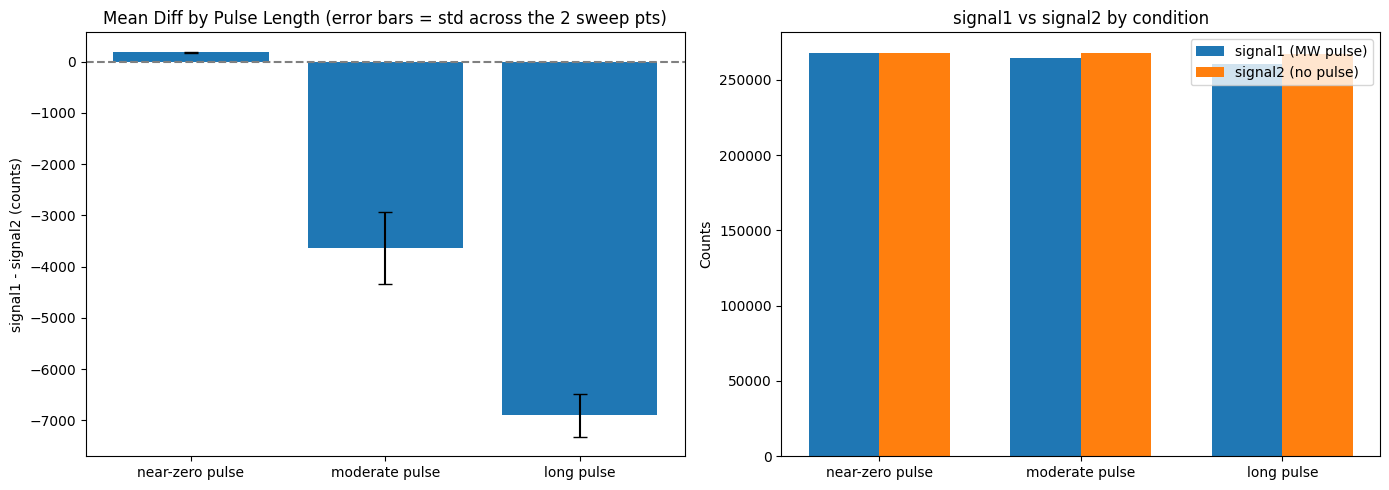

near-zero pulse: mean diff = 183.5, std = 10.5
moderate pulse: mean diff = -3636.0, std = 699.0
long pulse: mean diff = -6904.5, std = 420.5


In [ ]:

labels = ['near-zero pulse', 'moderate pulse', 'long pulse']
results = [d_zero, d_short, d_long]

means = []
stds = []

for d in results:
    diff = d.signal1 - d.signal2
    means.append(diff.mean())
    stds.append(diff.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar plot of mean diff with error bars
axes[0].bar(labels, means, yerr=stds, capsize=5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_ylabel('signal1 - signal2 (counts)')
axes[0].set_title('Mean Diff by Pulse Length (error bars = std across the 2 sweep pts)')

# raw signal1 vs signal2 for each condition, side by side
x = np.arange(len(labels))
width = 0.35

sig1_means = [d.signal1.mean() for d in results]
sig2_means = [d.signal2.mean() for d in results]

axes[1].bar(x - width/2, sig1_means, width, label='signal1 (MW pulse)')
axes[1].bar(x + width/2, sig2_means, width, label='signal2 (no pulse)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Counts')
axes[1].set_title('signal1 vs signal2 by condition')
axes[1].legend()

plt.tight_layout()
plt.show()

for label, mean, std in zip(labels, means, stds):
    print(f"{label}: mean diff = {mean:.1f}, std = {std:.1f}")

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Run Rabi </h3>
</div>



In [ ]:
n_passes = 10
reps_per_pass = 30000   # 10 * 200,000 = 2,000,000 total, same as before

sweep_start_tns = 24
sweep_stop_tns = 4000
sweep_step_tns = 8

signal1_sum = None
signal2_sum = None
reference1_sum = None
reference2_sum = None
resonance_fMHz=2015

for i in range(n_passes):
    config = copy(default_config)

    config.mw_gain = 4000
    config.mw_fMHz = 3061
    config.pre_init = True
    config.relax_delay_treg = 500

    config.laser_on_tus = 15
    config.readout_integration_tns = 50
    config.readout_reference_start_tus = 10
    config.mw_readout_delay_treg = 35
    config.laser_readout_offset_treg = 200

    config.add_linear_sweep('mw', 'tns', start=sweep_start_tns, stop=sweep_stop_tns, delta=sweep_step_tns)
    config.reps = reps_per_pass

    SetPower(70)
    prog = qd.RabiSweep(config)
    d_pass = prog.acquire(progress=True)
    Off()

    if signal1_sum is None:
        signal1_sum = d_pass.signal1.copy()
        signal2_sum = d_pass.signal2.copy()
        reference1_sum = d_pass.reference1.copy()
        reference2_sum = d_pass.reference2.copy()
        t = d_pass.sweep_tus
    else:
        signal1_sum += d_pass.signal1
        signal2_sum += d_pass.signal2
        reference1_sum += d_pass.reference1
        reference2_sum += d_pass.reference2

    print(f"pass {i+1}/{n_passes} done")

    del prog, d_pass
    gc.collect()

# average across passes
signal1_avg = signal1_sum / n_passes
signal2_avg = signal2_sum / n_passes
reference1_avg = reference1_sum / n_passes
reference2_avg = reference2_sum / n_passes

diff = signal1_avg - signal2_avg



experiment_folder = create_experiment_folder("Rabi")
experiment_id = experiment_folder.name

params = {
    "experiment_id": experiment_id,
    "timestamp": datetime.now().isoformat(),
    "laser_power": 70,
    "mw_gain": 5000,
    "resonance_fMHz": 3061,
    "n_passes": n_passes,
    "reps_per_pass": reps_per_pass,
    "total_reps": n_passes * reps_per_pass,
    "sweep_start_tns": sweep_start_tns,
    "sweep_stop_tns": sweep_stop_tns,
    "sweep_step_tns": sweep_step_tns,
}
save_metadata(experiment_folder, params)

np.savez(
    experiment_folder / "rabi_data.npz",
    pulse_length_us=t,
    signal1=signal1_avg,
    signal2=signal2_avg,
    reference1=reference1_avg,
    reference2=reference2_avg,
    diff=diff,
)

np.savetxt(
    experiment_folder / "rabi_data.csv",
    np.column_stack([t, signal1_avg, signal2_avg, reference1_avg, reference2_avg, diff]),
    delimiter=",",
    header="pulse_length_us,signal1,signal2,reference1,reference2,diff",
    comments=""
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t, diff, s=20)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('pulse length (us)')
ax.set_ylabel('signal1 - signal2 (counts)')
ax.set_title(f'Rabi: Interleaved-Averaged Difference ({n_passes} passes)\n{experiment_id}')
fig.savefig(experiment_folder / "rabi_difference_interleaved.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Experiment saved to: {experiment_folder}")

In [ ]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 70
mw_gain = 4000
resonance_fMHz = 2015
sweep_start_tns = 24
sweep_stop_tns = 4000       
sweep_step_tns = 10         
reps = 50000

# ---- Setup ----
SetPower(laser_power)

config.mw_gain = mw_gain
config.mw_fMHz = resonance_fMHz
config.pre_init = True
config.relax_delay_treg = 500

config.laser_on_tus = 15
config.readout_integration_tns = 50
config.readout_reference_start_tus = 10
config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 200

config.add_linear_sweep('mw', 'tns', start=sweep_start_tns, stop=sweep_stop_tns, delta=sweep_step_tns)
config.reps = reps

# ---- Run ----
prog = qd.RabiSweep(config)
d = prog.acquire(progress=True)

Off()

# ---- Saving ----
experiment_folder = create_experiment_folder("Rabi")
experiment_id = experiment_folder.name

# ---- Metadata ----
params = {
    "experiment_id": experiment_id,
    "timestamp": datetime.now().isoformat(),
    "laser_power": laser_power,
    "mw_gain": mw_gain,
    "resonance_fMHz": resonance_fMHz,
    "reps": reps,
    "sweep_start_tns": sweep_start_tns,
    "sweep_stop_tns": sweep_stop_tns,
    "sweep_step_tns": sweep_step_tns,
    "relax_delay_treg": config.relax_delay_treg,
    "laser_on_tus": config.laser_on_tus,
    "readout_integration_tns": config.readout_integration_tns,
    "readout_reference_start_tus": config.readout_reference_start_tus,
    "mw_readout_delay_treg": config.mw_readout_delay_treg,
    "laser_readout_offset_treg": config.laser_readout_offset_treg,
}
save_metadata(experiment_folder, params)

# ---- Raw + derived data ----
t = d.sweep_tus
diff = d.signal1 - d.signal2

np.savez(
    experiment_folder / "rabi_data.npz",
    pulse_length_us=t,
    signal1=d.signal1,
    signal2=d.signal2,
    reference1=d.reference1,
    reference2=d.reference2,
    diff=diff,
)

np.savetxt(
    experiment_folder / "rabi_data.csv",
    np.column_stack([t, d.signal1, d.signal2, d.reference1, d.reference2, diff]),
    delimiter=",",
    header="pulse_length_us,signal1,signal2,reference1,reference2,diff",
    comments=""
)

# ---- Plot 1: signal/reference overview ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(t, d.signal1, label='signal1 (MW pulse)')
axes[0].plot(t, d.signal2, label='signal2 (no pulse, reference)')
axes[0].set_xlabel('pulse length (us)')
axes[0].set_ylabel('Counts')
axes[0].set_title(f'Rabi: Raw Signal Counts\n{experiment_id}')
axes[0].legend()

axes[1].plot(t, d.reference1, label='reference1')
axes[1].plot(t, d.reference2, label='reference2')
axes[1].set_xlabel('pulse length (us)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Rabi: Reference Counts (should stay flat)')
axes[1].legend()

axes[2].plot(t, d.contrast)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('pulse length (us)')
axes[2].set_ylabel('Contrast (%)')
axes[2].set_title('Rabi: Contrast')

plt.tight_layout()
fig.savefig(experiment_folder / "rabi_signals_reference.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Plot 2: raw difference ----
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(t, diff)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel('pulse length (us)')
ax2.set_ylabel('signal1 - signal2 (counts)')
ax2.set_title(f'Rabi: Raw Signal Difference\n{experiment_id}')

fig2.savefig(experiment_folder / "rabi_difference.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Experiment saved to: {experiment_folder}")

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">  Fit Rabi </h3>
</div>



# 8. T<sub>1</sub> Delay Sweep <a class="anchor" id="nineth-bullet"></a>


## 8a. Configuration, Measurement, and Plotting

In [34]:
SetPower(0.1)

In [8]:
config = copy(default_config)

# ---- Experimental Parameters (knobs) ----
laser_power = 70
mw_gain = 4000
resonance_fMHz = 2080        # set to your ODMR dip center
mw_pulse_tns = 3000          # long saturating pulse, no Rabi needed
delay_start_tus = 0.5
delay_stop_tus = 65
scaling_factor = '5/4'
reps = 200000

# ---- Setup ----
SetPower(laser_power)

config.mw_gain = mw_gain
config.mw_fMHz = resonance_fMHz
config.mw_pi2_tns = mw_pulse_tns / 2   # code plays 2 x pi2 back to back

config.pre_init = True
config.relax_delay_treg = 6150
config.laser_on_tus = 15
config.readout_integration_tus = 2
config.readout_reference_start_tus = 12
config.mw_readout_delay_treg = 35
config.laser_readout_offset_treg = 206

config.add_exponential_sweep('delay', 'tus', start=delay_start_tus, stop=delay_stop_tus, scaling_factor=scaling_factor)
config.reps = reps

# ---- Run ----
prog = qd.T1DelaySweep(config)
d = prog.acquire(progress=True)

Off()

# ---- Saving ----
experiment_folder = create_experiment_folder("T1_MWref")
experiment_id = experiment_folder.name

params = {
    "experiment_id": experiment_id,
    "timestamp": datetime.now().isoformat(),
    "laser_power": laser_power,
    "mw_gain": mw_gain,
    "resonance_fMHz": resonance_fMHz,
    "mw_pulse_tns": mw_pulse_tns,
    "reps": reps,
    "delay_start_tus": delay_start_tus,
    "delay_stop_tus": delay_stop_tus,
    "scaling_factor": scaling_factor,
    "relax_delay_treg": config.relax_delay_treg,
    "laser_on_tus": config.laser_on_tus,
    "readout_integration_tus": config.readout_integration_tus,
    "readout_reference_start_tus": config.readout_reference_start_tus,
    "mw_readout_delay_treg": config.mw_readout_delay_treg,
    "laser_readout_offset_treg": config.laser_readout_offset_treg,
}
save_metadata(experiment_folder, params)

t = d.sweep_tus
np.savez(
    experiment_folder / "t1_mwref_data.npz",
    delay_us=t,
    signal1=d.signal1,
    signal2=d.signal2,
    reference1=d.reference1,
    reference2=d.reference2,
)

# ---- Plot raw ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, d.signal1, 'o-', label='signal1 (no MW)')
axes[0].plot(t, d.signal2, 'o-', label='signal2 (MW pulse)')
axes[0].set_xlabel('delay (us)')
axes[0].set_ylabel('Counts')
axes[0].set_title(f'T1 with MW reference: Raw Signal\n{experiment_id}')
axes[0].legend()

axes[1].plot(t, d.reference1, 'o-', label='reference1')
axes[1].plot(t, d.reference2, 'o-', label='reference2')
axes[1].set_xlabel('delay (us)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Reference Counts')
axes[1].legend()

plt.tight_layout()
fig.savefig(experiment_folder / "t1_mwref_raw.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Experiment saved to: {experiment_folder}")

ConnectionClosedError: receiving: not enough data